# Anime Rating Analysis

## Context

Content on the movie portal is rated by the viewers. The movie portal also provides other information for each anime like the duration, number of people who have watched it,etc.

We want to identify the most important factors involved in rating an anime. You objective is to identify the important factors that influence a rating and building a predictive model to predict the rating on an anime.


## Objective

To analyze the data and build a linear regression model to predict the ratings of anime.


## Key Questions

1. What are the key factors influencing the rating an anime?
2. Can we build a good predictive model for rating an anime? What needs to be part of the performance assessment for the model?


## Data Information



**Data Dictionary**

- title - the title of anime
- description - the synopsis of the plot
- mediaType - format of publication
- eps - number of episodes (movies are considered 1 episode)
- duration - duration of an episode in minutes
- ongoing - whether it is ongoing
- sznOfRelease - the season of release (Winter, Spring, Fall)
- years_running - number of years the anime ran/is running
- studio_primary - primary studio of production
- studios_colab - whether there was a collaboration between studios to produce the anime
- contentWarn - whether anime has a content warning
- watched - number of users that completed it
- watching - number of users that are watching it
- wantWatch - number of users that want to watch it
- dropped - number of users that dropped it before completion
- rating - average user rating
- votes - number of votes that contribute to rating
- tag_Based_on_a_Manga - whether the anime is based on a manga
- tag_Comedy - whether the anime is of Comedy genre
- tag_Action - whether the anime is of Action genre
- tag_Fantasy - whether the anime is of Fantasy genre
- tag_Sci_Fi - whether the anime is of Sci-Fi genre
- tag_Shounen - whether the anime has a tag Shounen
- tag_Original_Work - whether the anime is an original work
- tag_Non_Human_Protagonists - whether the anime has any non-human protagonists
- tag_Drama - whether the anime is of Drama genre
- tag_Adventure - whether the anime is of Adventure genre
- tag_Family_Friendly - whether the anime is family-friendly
- tag_Short_Episodes - whether the anime has short episodes
- tag_School_Life - whether the anime is regarding school life
- tag_Romance - whether the anime is of Romance genre
- tag_Shorts - whether the anime has a tag Shorts
- tag_Slice_of_Life - whether the anime has a tag Slice of Life
- tag_Seinen - whether the anime has a tag Seinen
- tag_Supernatural - whether the anime has a tag Supernatural
- tag_Magic - whether the anime has a tag Magic
- tag_Animal_Protagonists - whether the anime has animal protagonists
- tag_Ecchi - whether the anime has a tag Ecchi
- tag_Mecha - whether the anime has a tag Mecha
- tag_Based_on_a_Light_Novel - whether the anime is based on a light novel
- tag_CG_Animation - whether the anime has a tag CG Animation
- tag_Superpowers - whether the anime has a tag Superpowers
- tag_Others - whether the anime has other tags
- tag_is_missing - whether tag is missing or not

### Import necessary libraries

In [2]:
# this will help in making the Python code more structured automatically (good coding practice)
#%load_ext nb_black

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\513414080.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
# loading the dataset
df = pd.read_csv("anime_data.csv")

In [4]:
# checking shape of the data
df.shape

(12101, 44)

In [5]:
# to view first 5 rows of the dataset
df.head(5)

,title,description,mediaType,eps,duration,ongoing,sznOfRelease,years_running,studio_primary,studios_colab,contentWarn,watched,watching,wantWatch,dropped,rating,votes,tag_Based_on_a_Manga,tag_Comedy,tag_Action,tag_Fantasy,tag_Sci_Fi,tag_Shounen,tag_Original_Work,tag_Non_Human_Protagonists,tag_Drama,tag_Adventure,tag_Family_Friendly,tag_Short_Episodes,tag_School_Life,tag_Romance,tag_Shorts,tag_Slice_of_Life,tag_Seinen,tag_Supernatural,tag_Magic,tag_Animal_Protagonists,tag_Ecchi,tag_Mecha,tag_Based_on_a_Light_Novel,tag_CG_Animation,tag_Superpowers,tag_Others,tag_missing
0,Fullmetal Alchemist: Brotherhood,The foundation of alchemy is based on the law ...,TV,64,NaN,False,Spring,1,Bones,0,1,103707.0,14351,25810,2656,4.702,86547,1,0,1,1,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,your name.,Mitsuha and Taki are two total strangers livin...,Movie,1,107.0,False,is_missing,0,Others,0,0,58831.0,1453,21733,124,4.663,43960,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0
2,A Silent Voice,"After transferring into a new school, a deaf g...",Movie,1,130.0,False,is_missing,0,Kyoto Animation,0,1,45892.0,946,17148,132,4.661,33752,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,Haikyuu!! Karasuno High School vs Shiratorizaw...,"Picking up where the second season ended, the ...",TV,10,NaN,False,Fall,0,Production I.G,0,0,25134.0,2183,8082,167,4.660,17422,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,Attack on Titan 3rd Season: Part II,The battle to retake Wall Maria begins now! Wi...,TV,10,NaN,False,Spring,0,Others,0,1,21308.0,3217,7864,174,4.650,15789,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
# to view last 5 rows of the dataset
df.tail(5)

,title,description,mediaType,eps,duration,ongoing,sznOfRelease,years_running,studio_primary,studios_colab,contentWarn,watched,watching,wantWatch,dropped,rating,votes,tag_Based_on_a_Manga,tag_Comedy,tag_Action,tag_Fantasy,tag_Sci_Fi,tag_Shounen,tag_Original_Work,tag_Non_Human_Protagonists,tag_Drama,tag_Adventure,tag_Family_Friendly,tag_Short_Episodes,tag_School_Life,tag_Romance,tag_Shorts,tag_Slice_of_Life,tag_Seinen,tag_Supernatural,tag_Magic,tag_Animal_Protagonists,tag_Ecchi,tag_Mecha,tag_Based_on_a_Light_Novel,tag_CG_Animation,tag_Superpowers,tag_Others,tag_missing
12096,Sore Ike! Anpanman: Kirameke! Ice no Kuni no V...,Princess Vanilla is a princess in a land of ic...,Movie,1,NaN,False,is_missing,0,TMS Entertainment,0,0,22.0,1,29,1,2.807,10,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
12097,Hulaing Babies Petit,NaN,TV,12,5.0,False,Winter,0,Others,0,0,13.0,10,77,2,2.090,10,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
12098,Marco & The Galaxy Dragon,NaN,OVA,1,NaN,False,is_missing,0,is_missing,0,0,17.0,0,65,0,2.543,10,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
12099,Xing Chen Bian 2nd Season,Second season of Xing Chen Bian.,Web,3,24.0,True,is_missing,0,is_missing,0,0,40.5,31,22,0,3.941,10,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
12100,Ultra B: Black Hole kara no Dokusaisha BB!!,NaN,Movie,1,20.0,False,is_missing,0,Shin-Ei Animation,0,0,15.0,1,19,1,2.925,10,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [7]:
# let's create a copy of the data to avoid any changes to original data
data = df.copy()

In [8]:
# checking for duplicate values in the data
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
12096    False
12097    False
12098    False
12099    False
12100    False
Length: 12101, dtype: bool

- There are no duplicate values in the data.

In [9]:
# checking the names of the columns in the data
for column in data.columns:
    print(column)

title
description
mediaType
eps
duration
ongoing
sznOfRelease
years_running
studio_primary
studios_colab
contentWarn
watched
watching
wantWatch
dropped
rating
votes
tag_Based_on_a_Manga
tag_Comedy
tag_Action
tag_Fantasy
tag_Sci_Fi
tag_Shounen
tag_Original_Work
tag_Non_Human_Protagonists
tag_Drama
tag_Adventure
tag_Family_Friendly
tag_Short_Episodes
tag_School_Life
tag_Romance
tag_Shorts
tag_Slice_of_Life
tag_Seinen
tag_Supernatural
tag_Magic
tag_Animal_Protagonists
tag_Ecchi
tag_Mecha
tag_Based_on_a_Light_Novel
tag_CG_Animation
tag_Superpowers
tag_Others
tag_missing


In [10]:
# checking column datatypes and number of non-null values
data.dtypes

title                          object
description                    object
mediaType                      object
eps                             int64
duration                      float64
ongoing                          bool
sznOfRelease                   object
years_running                   int64
studio_primary                 object
studios_colab                   int64
contentWarn                     int64
watched                       float64
watching                        int64
wantWatch                       int64
dropped                         int64
rating                        float64
votes                           int64
tag_Based_on_a_Manga            int64
tag_Comedy                      int64
tag_Action                      int64
tag_Fantasy                     int64
tag_Sci_Fi                      int64
tag_Shounen                     int64
tag_Original_Work               int64
tag_Non_Human_Protagonists      int64
tag_Drama                       int64
tag_Adventur

Describe the results of the previous command

**Let's check for missing values in the data.**

In [11]:
# checking for missing values in the data
data.isna().sum()

title                            0
description                   4468
mediaType                        0
eps                              0
duration                      4636
ongoing                          0
sznOfRelease                     0
years_running                    0
studio_primary                   0
studios_colab                    0
contentWarn                      0
watched                          0
watching                         0
wantWatch                        0
dropped                          0
rating                           0
votes                            0
tag_Based_on_a_Manga             0
tag_Comedy                       0
tag_Action                       0
tag_Fantasy                      0
tag_Sci_Fi                       0
tag_Shounen                      0
tag_Original_Work                0
tag_Non_Human_Protagonists       0
tag_Drama                        0
tag_Adventure                    0
tag_Family_Friendly              0
tag_Short_Episodes  

comment on previous command

In [12]:
# Let's look at the statistical summary of the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
eps,12101.0,13.393356,57.925097,1.000,1.000,2.000,12.000,2527.000
duration,7465.0,24.230141,31.468171,1.000,4.000,8.000,30.000,163.000
years_running,12101.0,0.283200,1.152234,0.000,0.000,0.000,0.000,51.000
studios_colab,12101.0,0.051649,0.221326,0.000,0.000,0.000,0.000,1.000
contentWarn,12101.0,0.115362,0.319472,0.000,0.000,0.000,0.000,1.000
watched,12101.0,2862.605694,7724.347024,0.000,55.000,341.000,2026.000,161567.000
watching,12101.0,256.334435,1380.840902,0.000,2.000,14.000,100.000,74537.000
wantWatch,12101.0,1203.681431,2294.327380,0.000,49.000,296.000,1275.000,28541.000
dropped,12101.0,151.568383,493.931710,0.000,3.000,12.000,65.000,19481.000
rating,12101.0,2.949037,0.827385,0.844,2.304,2.965,3.616,4.702


describe the results of the previous command

**Let's look at the non-numeric columns.**

In [13]:
# filtering non-numeric columns
cat_columns = data.select_dtypes(exclude=np.number).columns
cat_columns

Index(['title', 'description', 'mediaType', 'ongoing', 'sznOfRelease',
       'studio_primary'],
      dtype='object')

In [14]:
# we will skip the title and description columns as they will have a lot of unique values
cat_col = ["mediaType", "ongoing", "sznOfRelease", "studio_primary"]

# printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

mediaType
TV             3993
Movie          1928
OVA            1770
Music Video    1290
Web            1170
DVD Special     803
Other           580
TV Special      504
is_missing       63
Name: count, dtype: int64
--------------------------------------------------
ongoing
False    11986
True       115
Name: count, dtype: int64
--------------------------------------------------
sznOfRelease
is_missing    8554
Spring        1135
Fall          1011
Winter         717
Summer         684
Name: count, dtype: int64
--------------------------------------------------
studio_primary
Others                  4340
is_missing              3208
Toei Animation           636
Sunrise                  430
J.C. Staff               341
MADHOUSE                 337
TMS Entertainment        317
Production I.G           271
Studio Deen              260
Studio Pierrot           221
OLM                      210
A-1 Pictures             194
AIC                      167
Shin-Ei Animation        164
Nippon Anima

There appear to be quite a few results under 'studio_primary' that indicate the main studio is either in the "others" or "is_missing" category. This means most of the entries will not be included in the largest studios.

This is a shame, since studio is likely the strongest predictor for rating.

In [15]:
# making another copy, in case I want to try again with the studio_primary column
data2 = data.copy()

In [16]:
data.drop(['title', 'description', 'studio_primary', 'sznOfRelease'], axis=1, inplace=True)

### We will drop the missing values in the dataset.

In [17]:
data.dropna(inplace=True)
data.shape

(7465, 40)

## Data Visualization

### Univariate Analysis

In [18]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### histograms and boxplots of the various columns

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


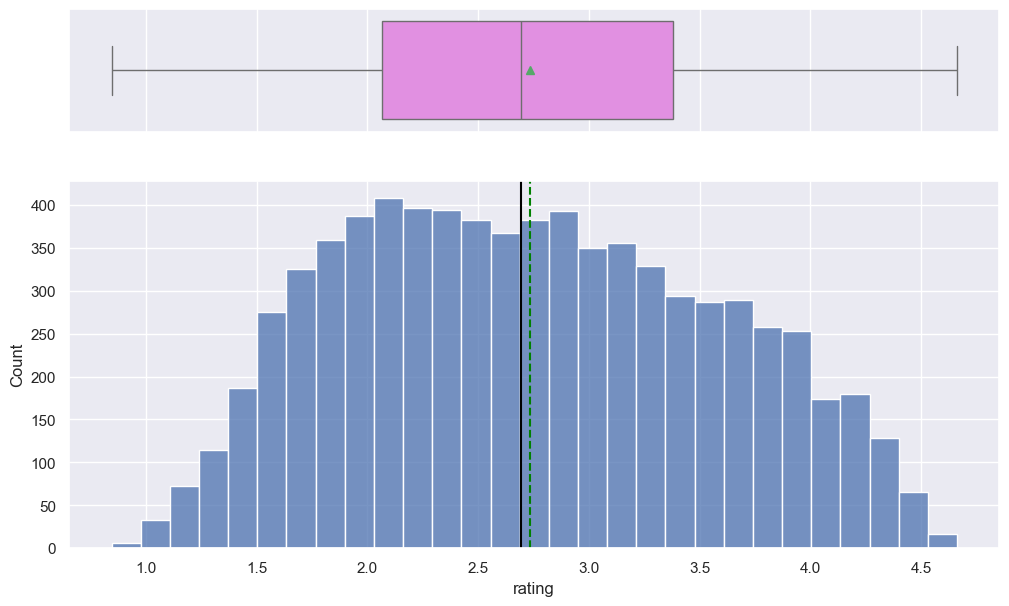

In [19]:
histogram_boxplot(data, "rating")

In [20]:
data.rating.mean()

2.7358113864701945

<b>Observations:</b>
<ul>
    <li>Ratings are relatively uniform</li>
    <li>Very slightly skewed right</li>
    <li>mean of 2.7</li>
</ul>

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


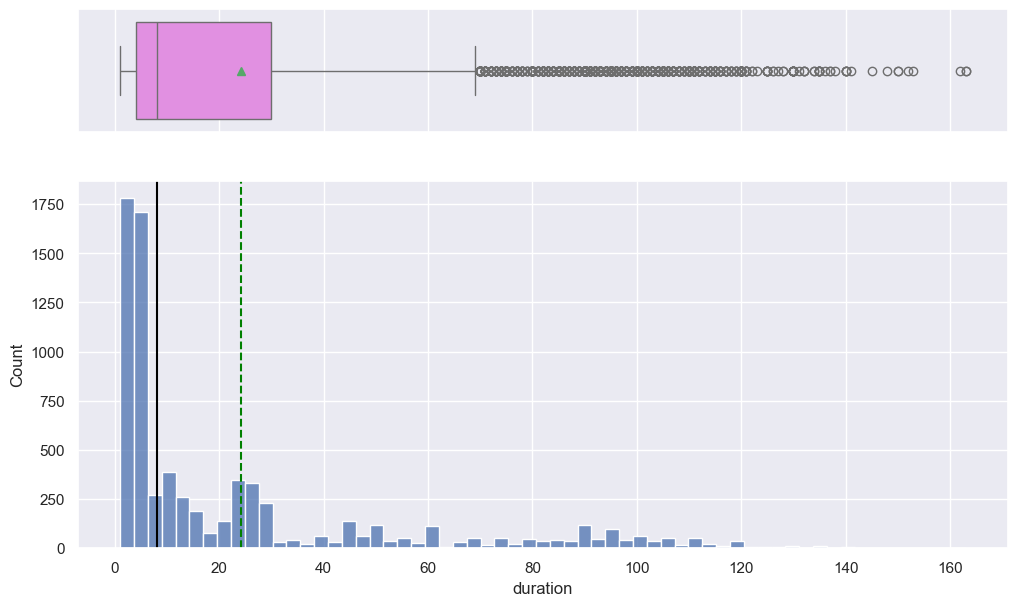

In [21]:
histogram_boxplot(data, "duration")

In [22]:
data.duration.mean()

24.230140656396518

<b>Observations:</b>
<ul>
    <li>Very skewed right</li>
    <li>Mean of 24</li>
    <li>Most grouped under 25</li>
</ul>

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


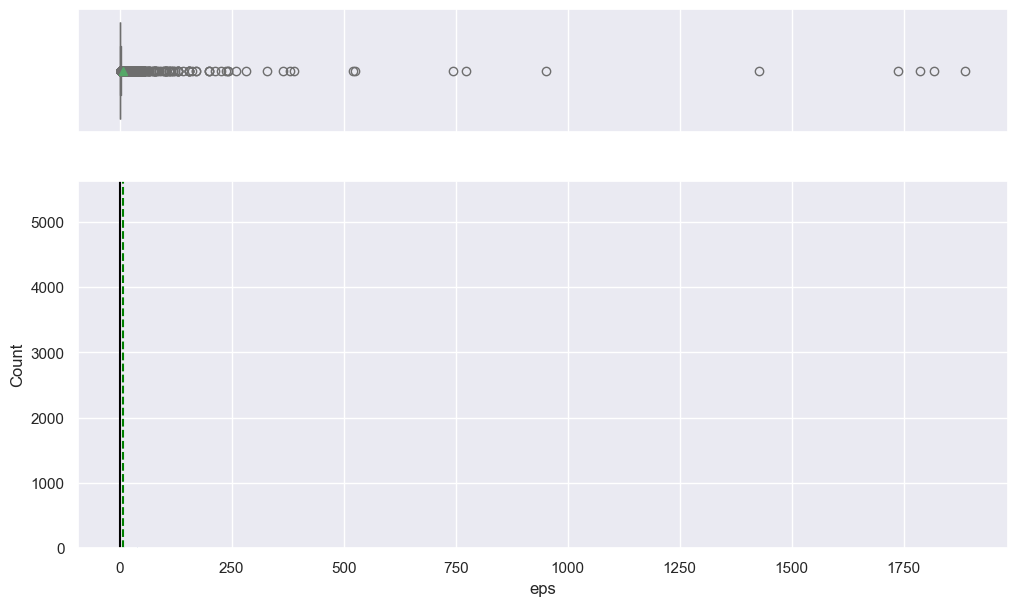

In [23]:
histogram_boxplot(data, "eps");

In [24]:
data.eps.mean()

6.612592096450101

<b>Observations:</b>
<ul>
    <li>Very severe outliers skewing data right</li>
    <li>Mean of 6.6</li>
    <li>Most are grouped under 25</li>
</ul>

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


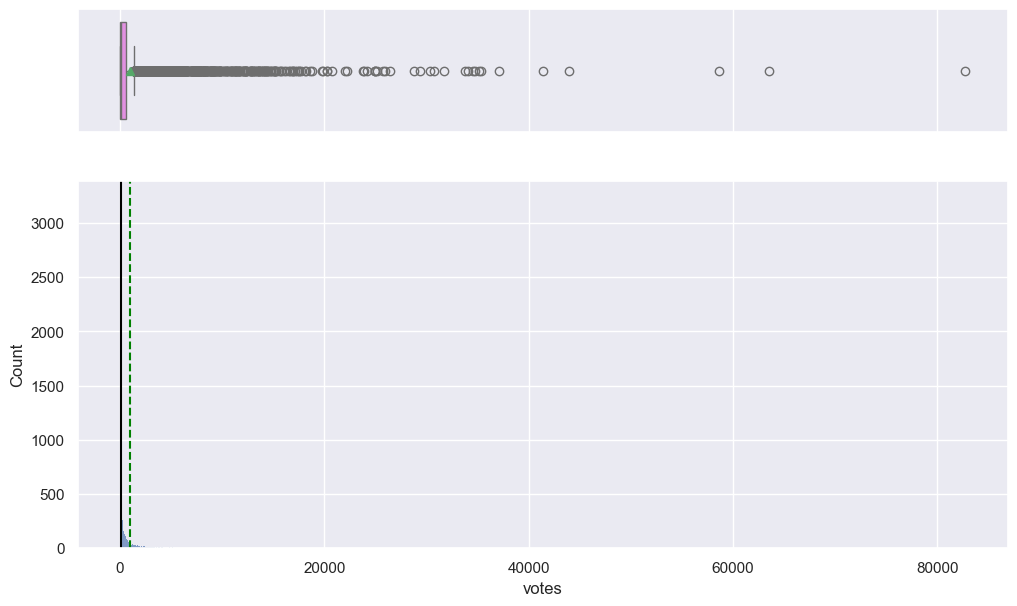

In [25]:
histogram_boxplot(data, "votes")

In [26]:
data.votes.mean()

957.9867381111856

<b>Observations:</b>
<ul>
    <li>Very severe outliers skewing data right</li>
    <li>Mean of 958</li>
    <li>Most are grouped under 1000</li>
</ul>

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


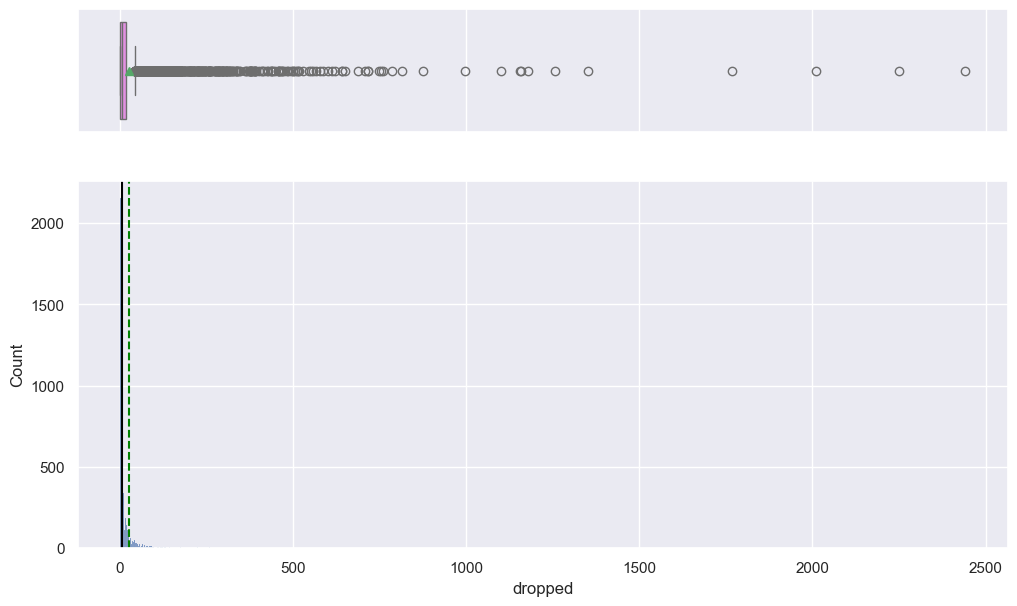

In [27]:
histogram_boxplot(data, "dropped")

In [28]:
data.dropped.mean()

25.272605492297387

<b>Observations:</b>
<ul>
    <li>Very severe outliers skewing data right</li>
    <li>Mean of 25.3</li>
    <li>Most are grouped under 50</li>
</ul>

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


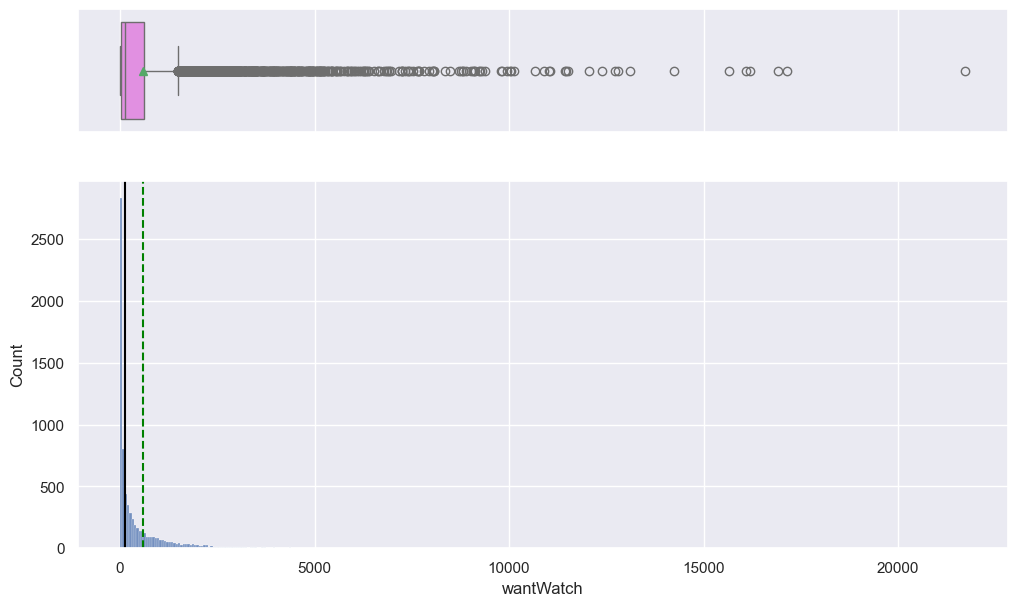

In [29]:
histogram_boxplot(data, "wantWatch")

In [30]:
data.wantWatch.mean()

600.6408573342264

<b>Observations:</b>
<ul>
    <li>Very severe outliers skewing data right</li>
    <li>Most are grouped under 750</li>
    <li>Mean of 600</li>
</ul>

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


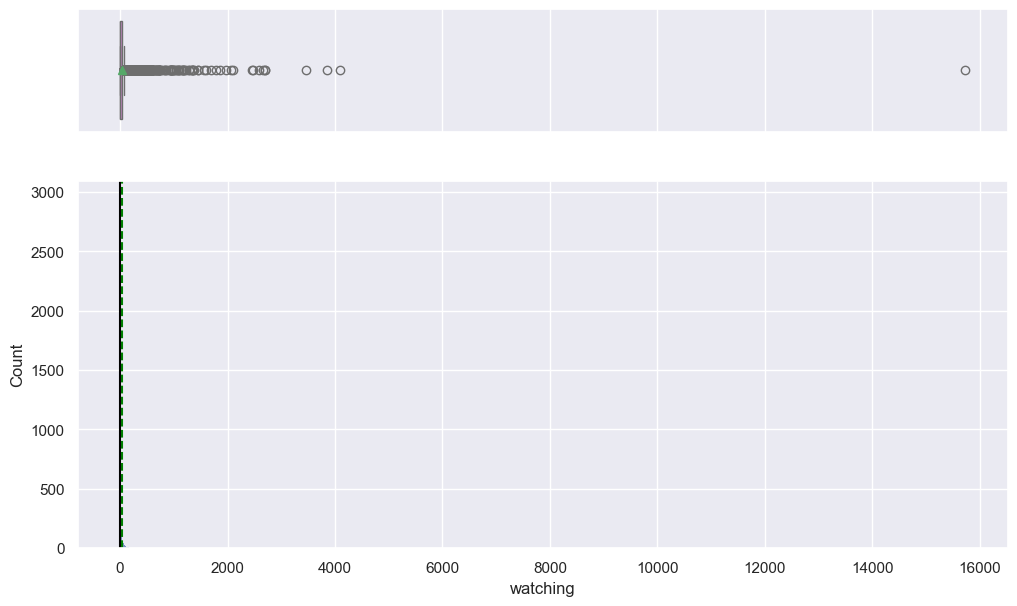

In [31]:
histogram_boxplot(data, "watching")

In [32]:
data.watching.mean()

45.36892163429337

<b>Observations:</b>
<ul>
    <li>Very severe outliers skewing data right</li>
    <li>Most are grouped under 50</li>
</ul>

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


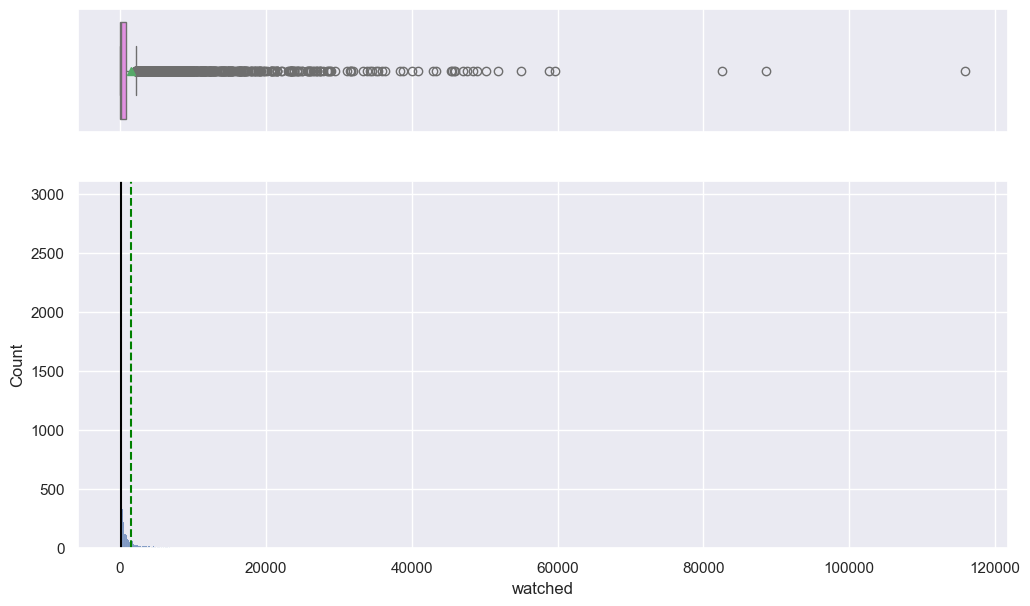

In [33]:
histogram_boxplot(data, "watched")

In [34]:
data.watched.mean()

1487.9557267247153

<b>Observations:</b>
<ul>
    <li>Very severe outliers skewing data right</li>
    <li>Most are grouped under 2000</li>
</ul>

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


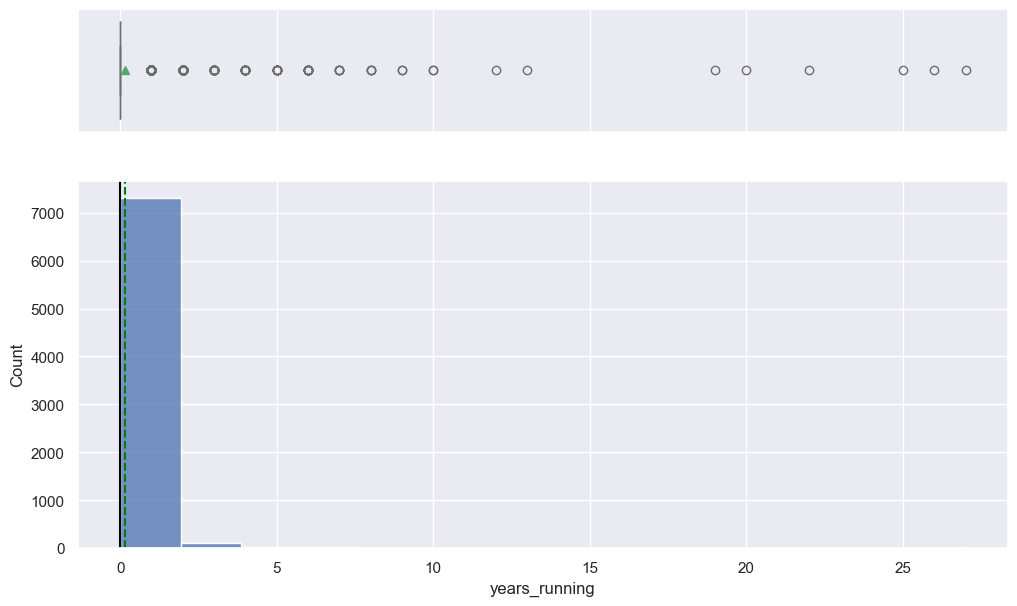

In [35]:
histogram_boxplot(data, "years_running")

In [36]:
data.years_running.mean()

0.1620897521768252

<b>Observations:</b>
<ul>
    <li>Severe outliers skewing data right</li>
    <li>Most are grouped under 5</li>
    <li>Mean of 0.16</li>
</ul>

### next column...repeat

In [37]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### `mediaType`

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Pyth

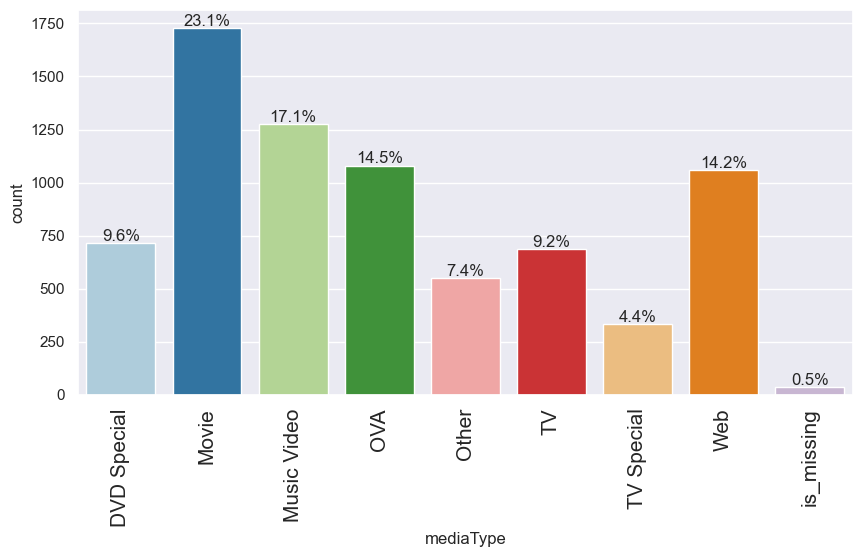

In [38]:
labeled_barplot(data, "mediaType", perc=True);

<b>Observations:</b>
<ul>
    <li>Relatively even distribution, among all categories</li>
    <li>Movie is most common, followed by Music Video, OVA, and Web</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


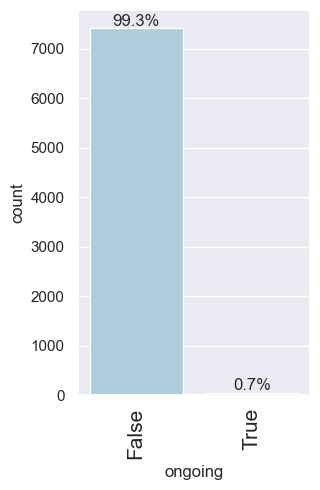

In [39]:
labeled_barplot(data, "ongoing", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't ongoing</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


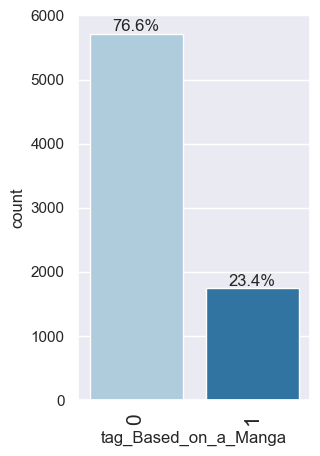

In [40]:
labeled_barplot(data, "tag_Based_on_a_Manga", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't based on a manga</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


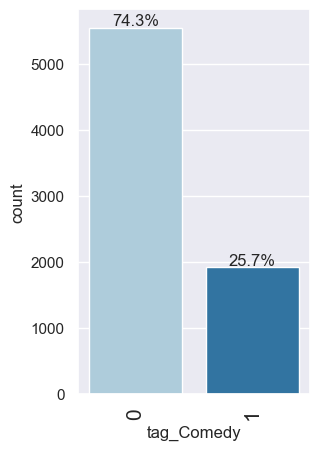

In [41]:
labeled_barplot(data, "tag_Comedy", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't comedy</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


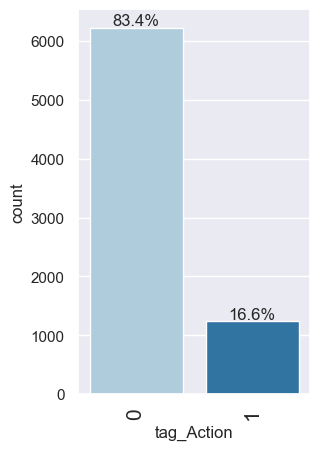

In [42]:
labeled_barplot(data, "tag_Action", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't action</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


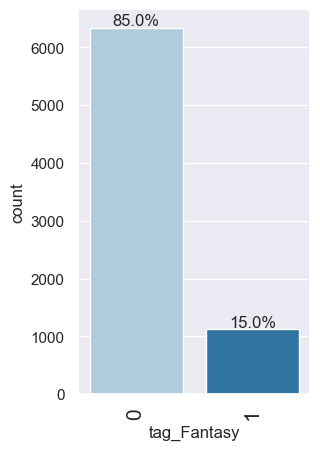

In [43]:
labeled_barplot(data, "tag_Fantasy", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't fantasy</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


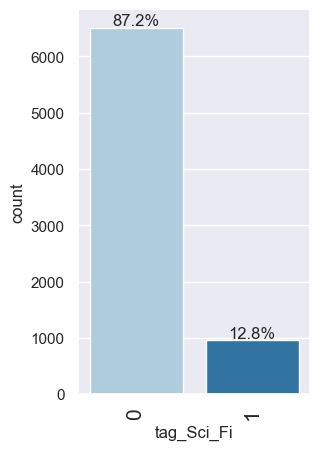

In [44]:
labeled_barplot(data, "tag_Sci_Fi", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't sci fi</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


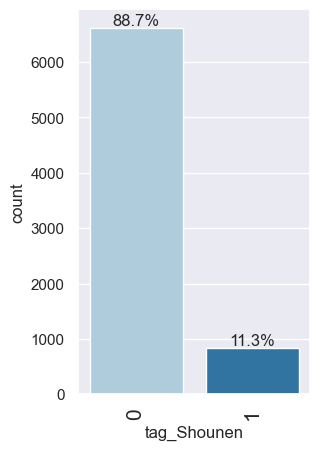

In [45]:
labeled_barplot(data, "tag_Shounen", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't shounen</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


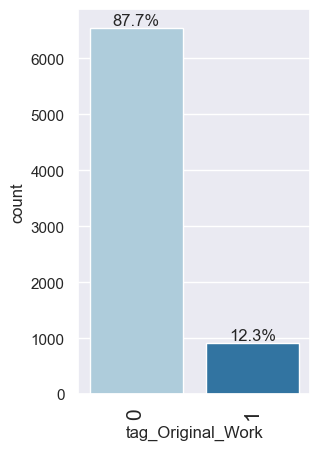

In [46]:
labeled_barplot(data, "tag_Original_Work", perc=True);

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


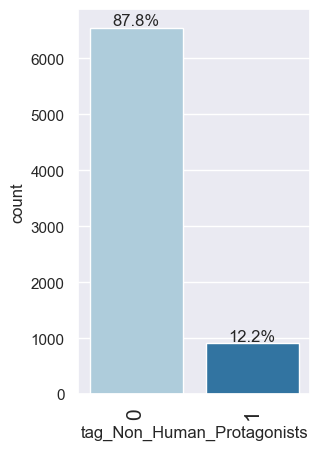

In [47]:
labeled_barplot(data, "tag_Non_Human_Protagonists", perc=True);

<b>Observations:</b>
<ul>
    <li>Most feature human protagonists</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


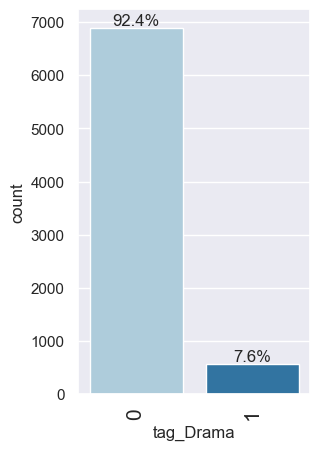

In [48]:
labeled_barplot(data, "tag_Drama", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't drama</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


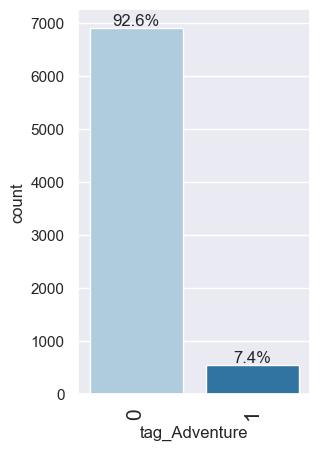

In [49]:
labeled_barplot(data, "tag_Adventure", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't adventure</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


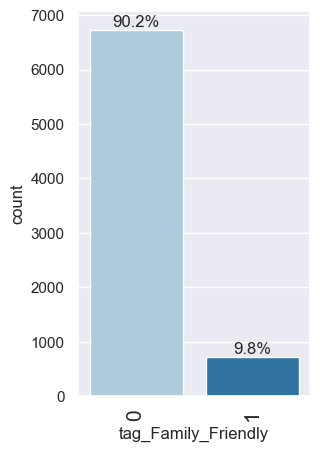

In [50]:
labeled_barplot(data, "tag_Family_Friendly", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't family friendly</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


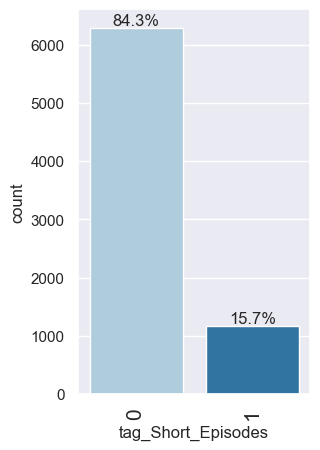

In [51]:
labeled_barplot(data, "tag_Short_Episodes", perc=True);

<b>Observations:</b>
<ul>
    <li>Most don't have short episodes</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


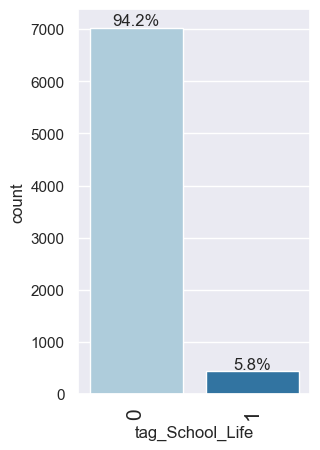

In [52]:
labeled_barplot(data, "tag_School_Life", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't about school life</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


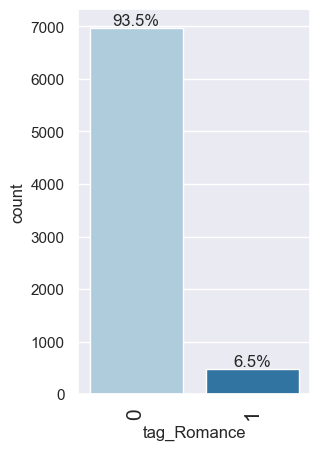

In [53]:
labeled_barplot(data, "tag_Romance", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't romance</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


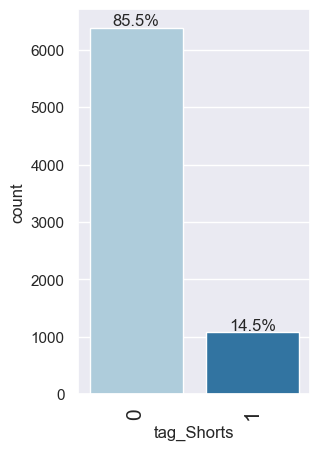

In [54]:
labeled_barplot(data, "tag_Shorts", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't shorts</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


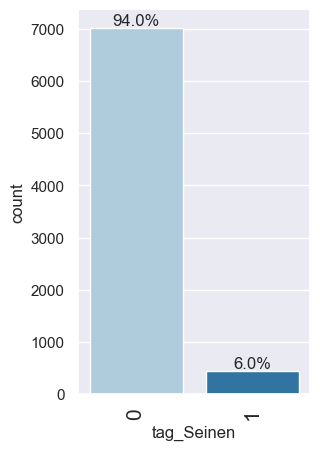

In [55]:
labeled_barplot(data, "tag_Seinen", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't seinen</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


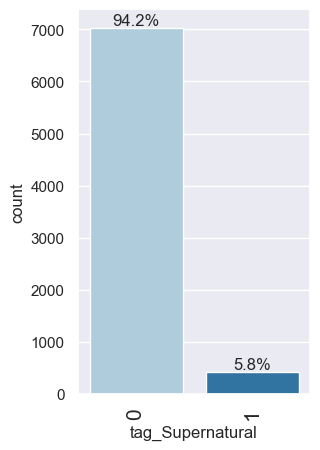

In [56]:
labeled_barplot(data, "tag_Supernatural", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't supernatural</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


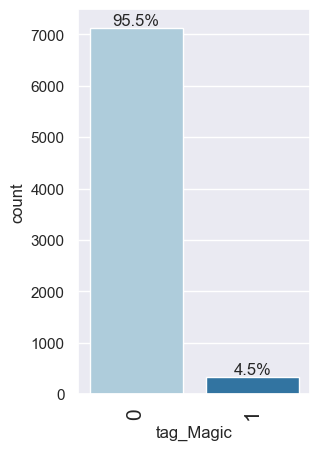

In [57]:
labeled_barplot(data, "tag_Magic", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't magic</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


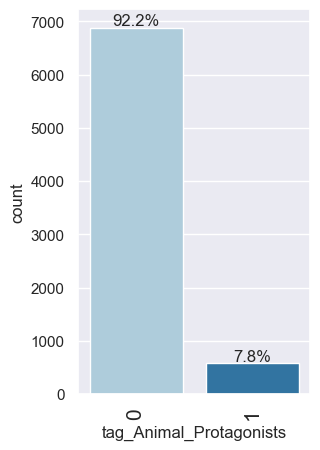

In [58]:
labeled_barplot(data, "tag_Animal_Protagonists", perc=True);

<b>Observations:</b>
<ul>
    <li>Most don't feature animal protagonists</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


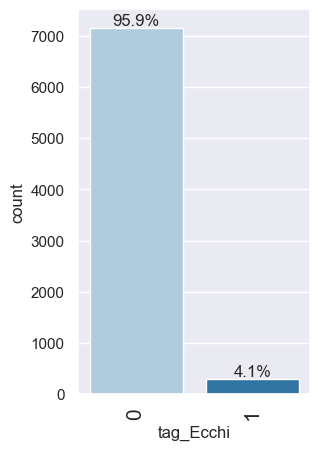

In [59]:
labeled_barplot(data, "tag_Ecchi", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't ecchi</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


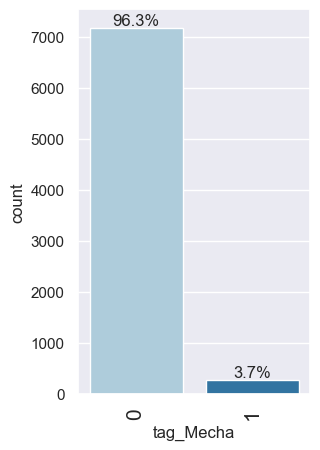

In [60]:
labeled_barplot(data, "tag_Mecha", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't mecha</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


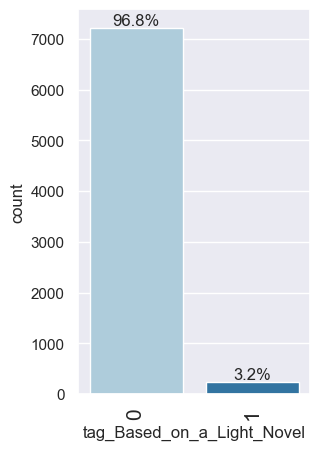

In [61]:
labeled_barplot(data, "tag_Based_on_a_Light_Novel", perc=True);

<b>Observations:</b>
<ul>
    <li>Most aren't based on a light novel</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


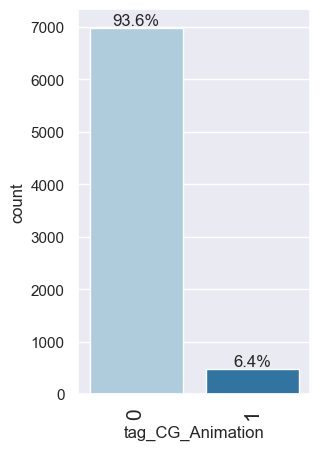

In [62]:
labeled_barplot(data, "tag_CG_Animation", perc=True);

<b>Observations:</b>
<ul>
    <li>Most don't feature cg animation</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


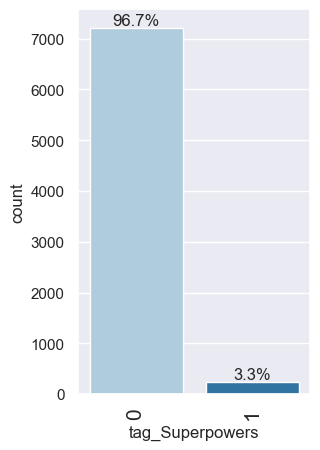

In [63]:
labeled_barplot(data, "tag_Superpowers", perc=True);

<b>Observations:</b>
<ul>
    <li>Most don't feature superpowers</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


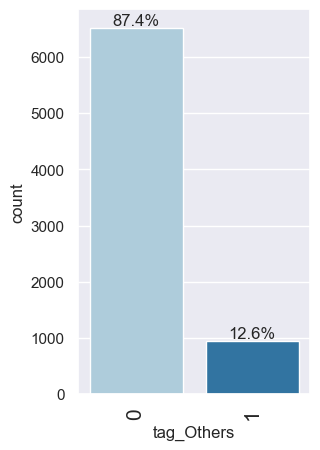

In [64]:
labeled_barplot(data, "tag_Others", perc=True);

<b>Observations:</b>
<ul>
    <li>Most don't have other tags</li>
</ul>

C:\Users\codyd\AppData\Local\Temp\ipykernel_18000\2559097902.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


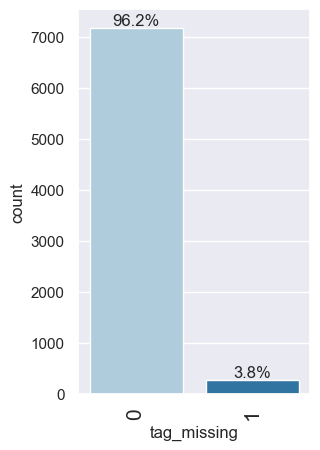

In [65]:
labeled_barplot(data, "tag_missing", perc=True);

<b>Observations:</b>
<ul>
    <li>Most don't have missing tags</li>
</ul>

### repeat the process for columns with similar data format

In [66]:
# creating a list of tag columns
tag_cols = [item for item in data.columns if "tag" in item]

# printing the number of occurrences of each unique value in each categorical column
for column in tag_cols:
    print(data[column].value_counts())
    print("-" * 50)

tag_Based_on_a_Manga
0    5718
1    1747
Name: count, dtype: int64
--------------------------------------------------
tag_Comedy
0    5545
1    1920
Name: count, dtype: int64
--------------------------------------------------
tag_Action
0    6227
1    1238
Name: count, dtype: int64
--------------------------------------------------
tag_Fantasy
0    6342
1    1123
Name: count, dtype: int64
--------------------------------------------------
tag_Sci_Fi
0    6511
1     954
Name: count, dtype: int64
--------------------------------------------------
tag_Shounen
0    6625
1     840
Name: count, dtype: int64
--------------------------------------------------
tag_Original_Work
0    6548
1     917
Name: count, dtype: int64
--------------------------------------------------
tag_Non_Human_Protagonists
0    6553
1     912
Name: count, dtype: int64
--------------------------------------------------
tag_Drama
0    6896
1     569
Name: count, dtype: int64
---------------------------------------------

<b>Most common tags are:</b>
<ul>
    <li>Comedy</li>
    <li>Based on a manga</li>
    <li>Action</li>
    <li>Fantasy</li>
    <li>Short episodes</li>
</ul>

### Bivariate analysis

**We will not analyze the *tag* columns for correlation check as they have only 0 or 1 values.**

In [67]:
# creating a list of non-tag columns
corr_cols = [item for item in data.columns if "tag" not in item]
print(corr_cols)

['mediaType', 'eps', 'duration', 'ongoing', 'years_running', 'studios_colab', 'contentWarn', 'watched', 'watching', 'wantWatch', 'dropped', 'rating', 'votes']


In [68]:
data3 = data.copy()
# Encoding the only categorical, string-based column in the list above
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data['mediaType'] = label_encoder.fit_transform(data['mediaType'])

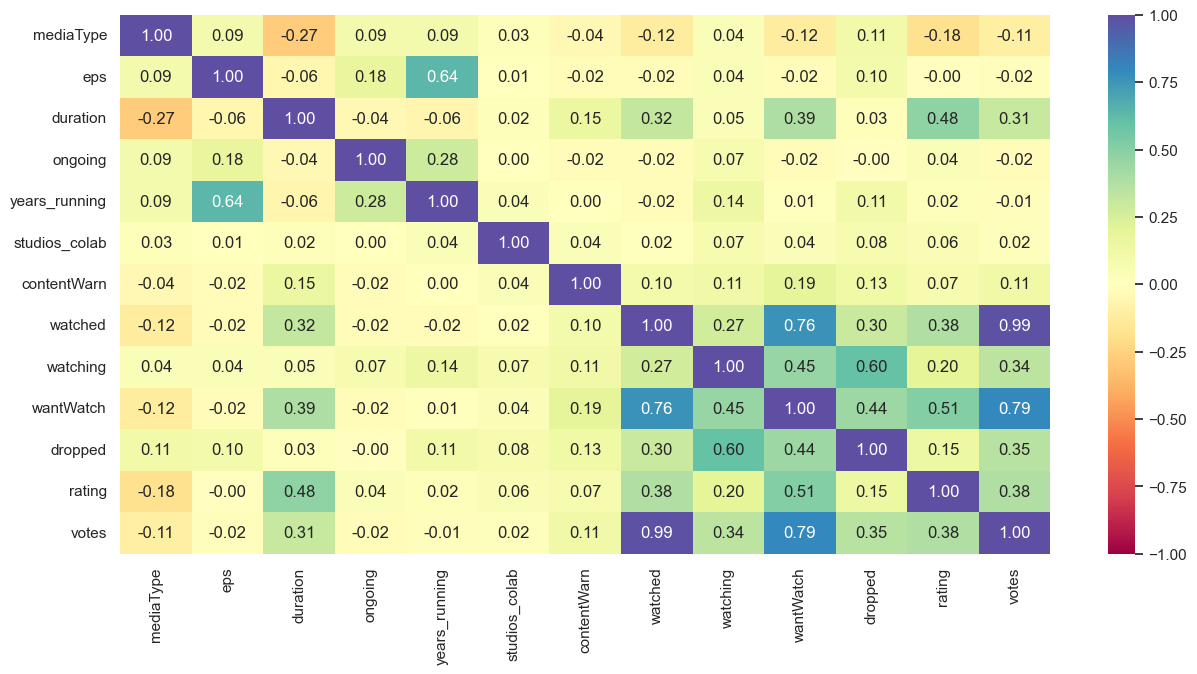

In [69]:
plt.figure(figsize=(15, 7))
sns.heatmap(
     data[corr_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
 )
plt.show()

<b>Observations:</b>
<ul>
    <li>Strongest correlation is between watching/votes</li>
    <li>Then votes/wantWatch, wantWatch/watched, eps/years_running, dropped/watching</li>
</ul>

### Check the variation of the dependent variable `rating` with some of the categorical columns in our data

### `mediaType` vs `rating`

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


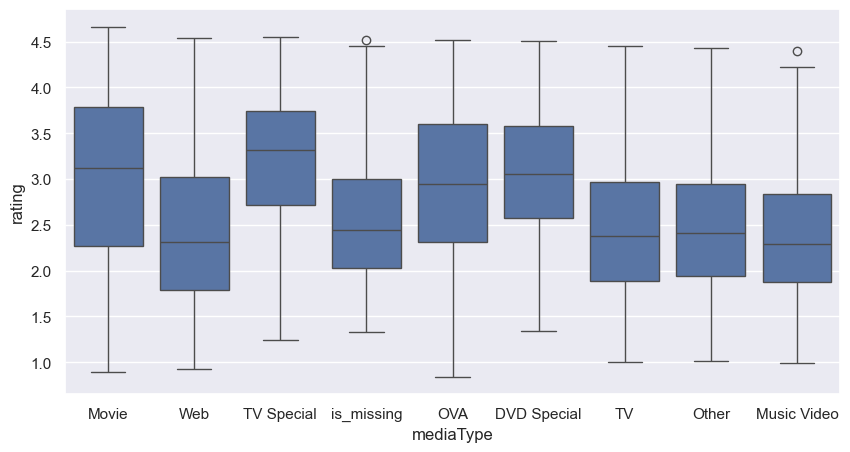

In [70]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="mediaType", y="rating", data=data3)
plt.show()

<b>Observations:</b>
<ul>
    <li>TV Special appears to have the highest average rating</li>
    <li>Music Video appears to have the lowest average rating</li>
</ul>

### try some more vs rating

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


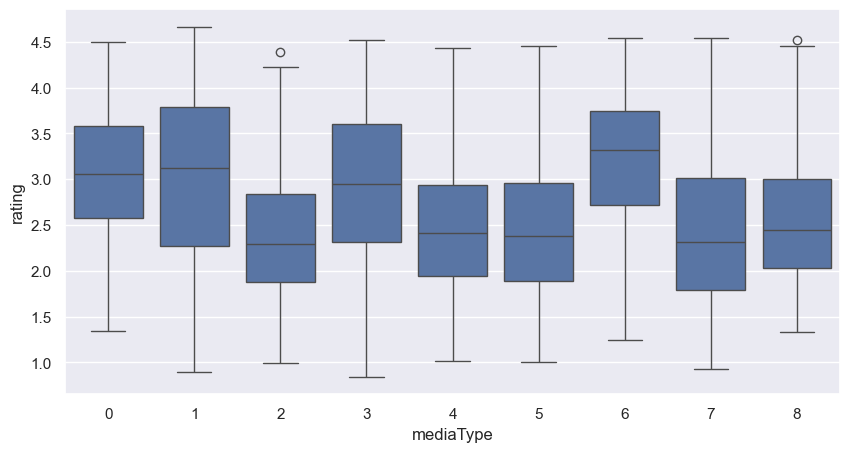

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


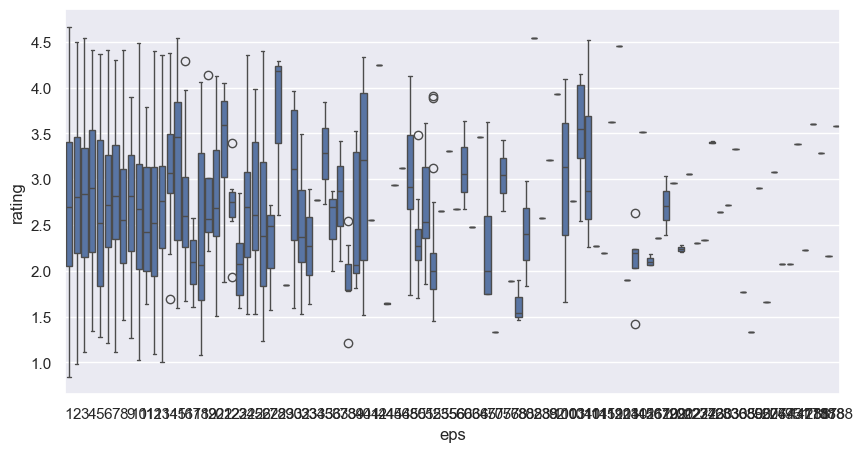

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


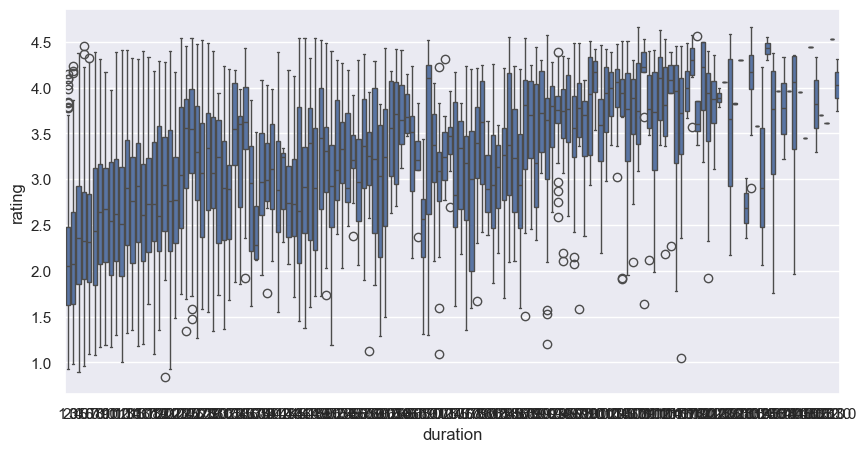

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


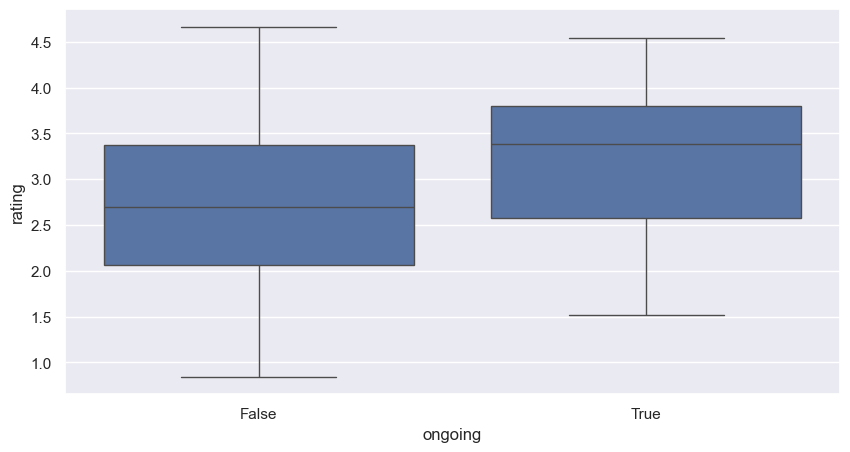

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


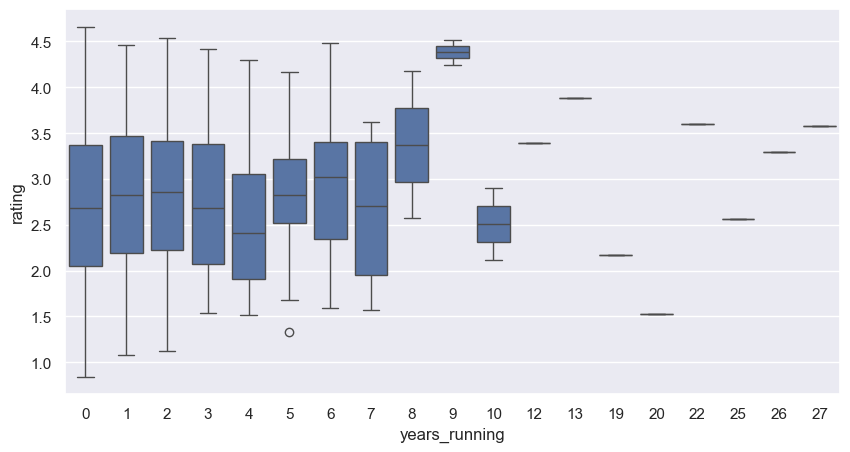

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


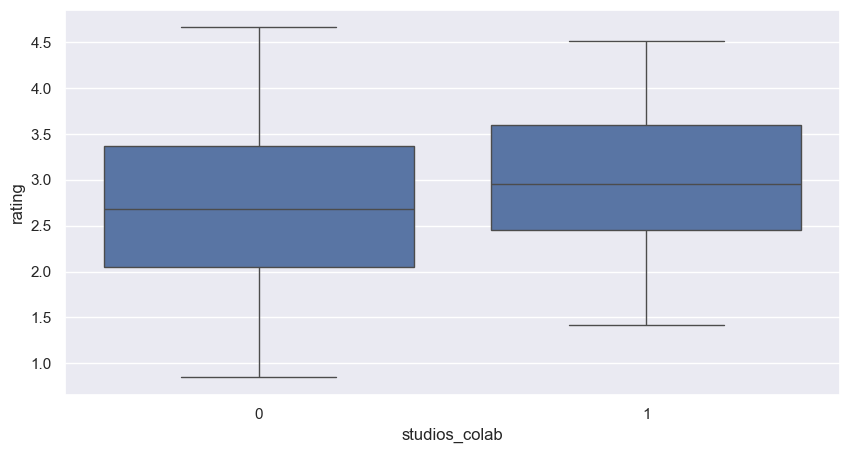

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


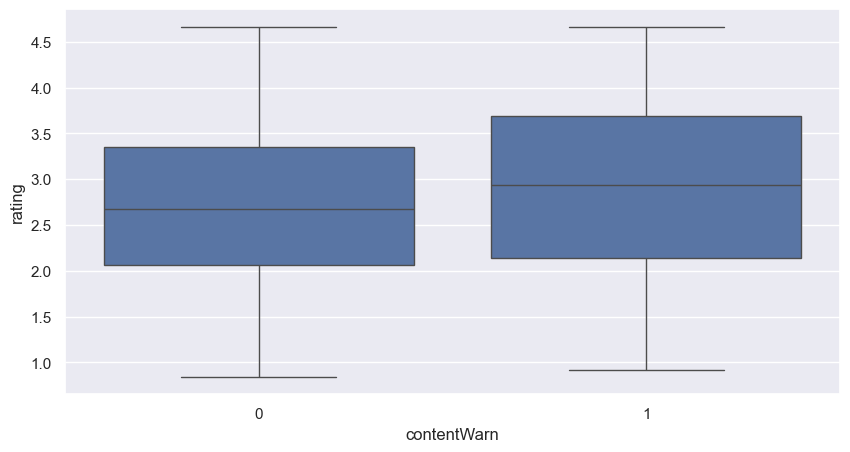

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


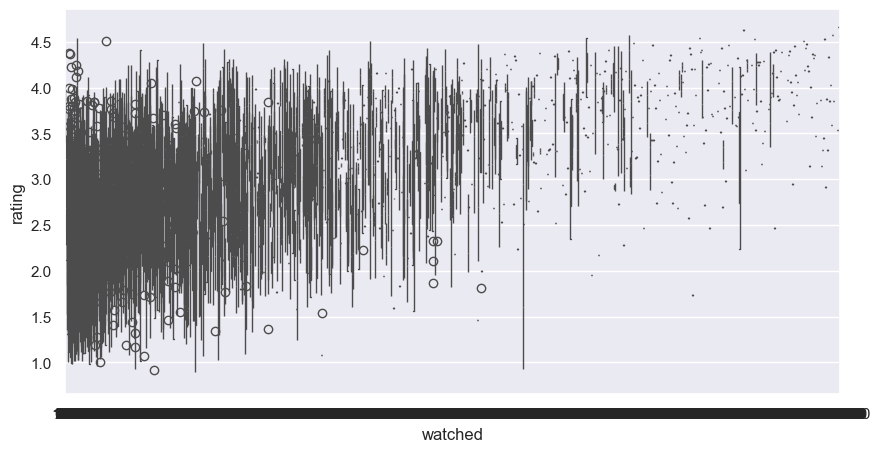

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


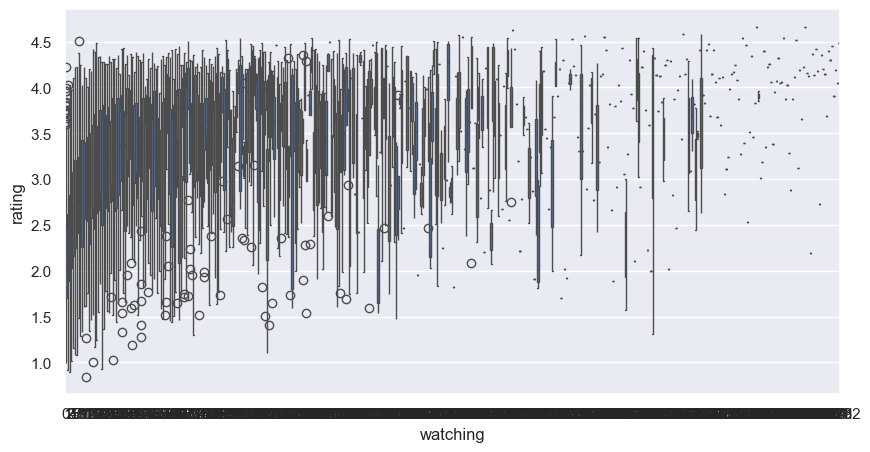

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


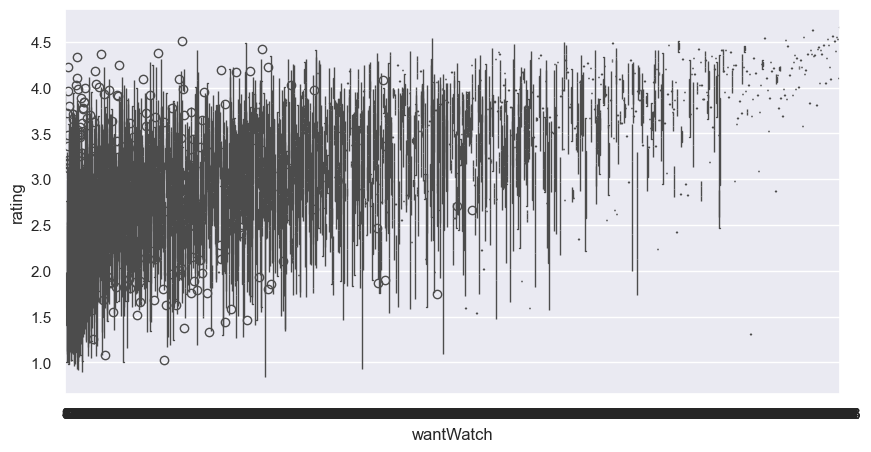

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


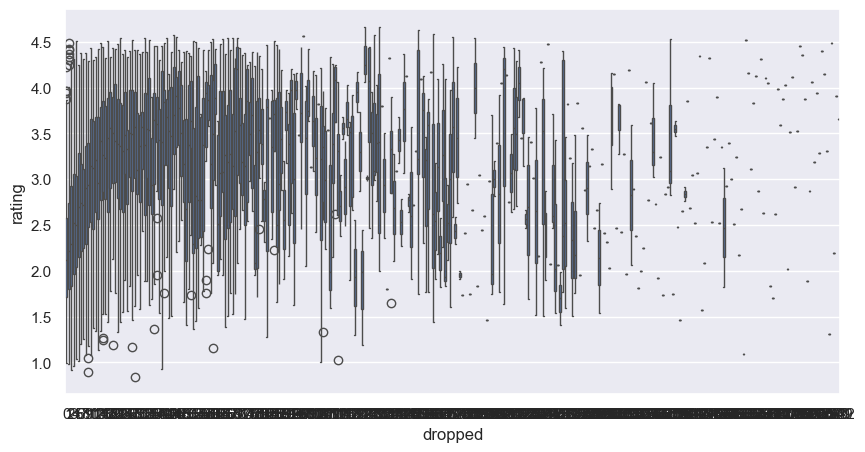

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


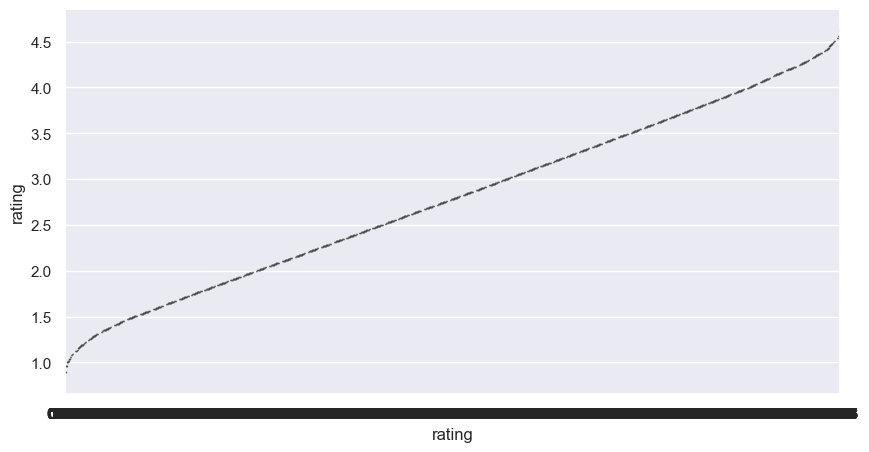

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


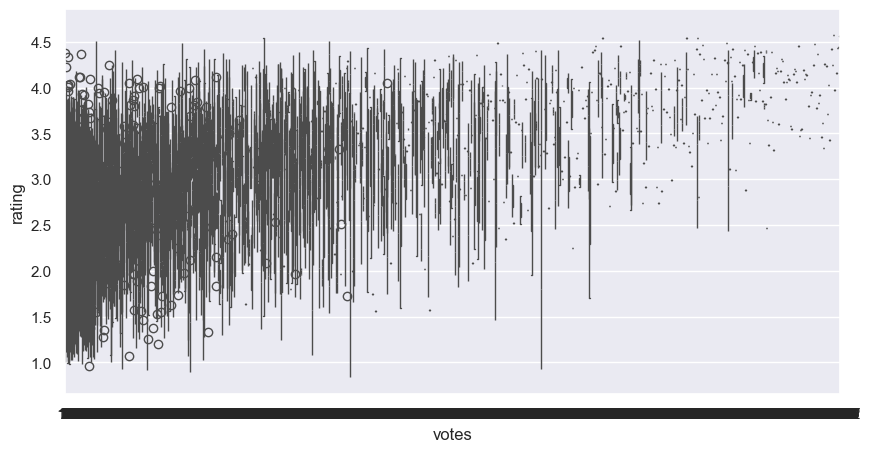

In [71]:
for column in data[corr_cols]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=column, y="rating", data=data)
    plt.show()

<b>Observations:</b>
<ul>
    <li>The larger the value for wantWatch, the higher the rating</li>
    <li>The more the votes, the higher the rating, to a point</li>
    <li>The more drops, the lower the rating, until a certain point (heavily skewed by number of people who have watched overall)</li>
    <li>The more watching, the higher the rating, to a point</li>
    <li>studios_colab being positive means higher rating</li>
    <li>years_running hyper-specific to a handful of anime, passed 4-5 years</li>
    <li>Longer duration means higher rating</li>
</ul>

### <a id='link1'>Summary of EDA</a>

**Data Description:**

- Many columns originally that were not necessarily indicative of anything relevant to the rating (years_running, eps, etc.)
- Strongest indicator for rating appears to be wantWatch, watching, watched, or duration
- Primary studio would likely be the strongest indicator, by far, if not for the "others" and "is_missing" values associated with the column.
- Had to encode mediaType, so as to accomodate the correlation maps
- Still many "is_missing" values present in mediaType, which could also influence the data


**Observations from EDA:**

As stated above, there were a handful of columns that were clearly not indicative of rating, like title and description, as well as some that were more subtle, but still not indicative, like eps and years_running. This is mostly due to the fact that most anime will fall into a strict template, in terms of the number of episodes/seasons, and length of the show overall (i.e. shows that generate a lot of money will obviously run longer than 1 season, but 90% of them don't). This is especially true for shows that have more than 2 seasons, as a 2nd season is generally seen as a luxury on its own, so a show having even more than 2 already indicates that it is an outlier, when compared to all others. Because of this, rows in the dataset that indicate a show running for >4 years will number under a dozen (e.g. number of shows running for 9 years is 1, 10 is 1, etc.). 

Additionally, it is highly unfortunate that there is so much muddy data present in the primary_studio column, since this is most likely the strongest predictor for high ratings, as only the richest studios will be able to undertake multiple projects at once. If they are able to do this, that also means they probably have access to better technology and talent for producing anime, so they will likely score higher ratings on average, as a result.

## Model Building

### Define independent and dependent variables

In [72]:
X = data.drop(["rating"], axis=1)
y = data["rating"]

In [73]:
X.shape

(7465, 39)

### Split the data into train and test

In [74]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [75]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 5225
Number of rows in test data = 2240


### Fitting a linear model

In [76]:
lin_reg_model = LinearRegression()
lin_reg_model.fit(x_train, y_train)

LinearRegression()

**Let us check the coefficients and intercept of the model, which are the parameters we learned.**

In [77]:
coef_df = pd.DataFrame(
    np.append(lin_reg_model.coef_, lin_reg_model.intercept_),
    index=x_train.columns.tolist() + ["Intercept"],
    columns=["Coefficients"],
)
coef_df

,Coefficients
mediaType,-0.006742
eps,0.000213
duration,0.005365
ongoing,0.500895
years_running,0.019200
studios_colab,0.131218
contentWarn,-0.212254
watched,0.000107
watching,0.000140
wantWatch,0.000245


### Coefficient Interpretations

<ul>
    <li>Highest coefficient is ongoing</li>
    <li>Lowest coefficient is tag_Short_Episodes</li>
</ul>

### Model performance check

* Refer to Canvas for the description of RMSE, MAE, $R^2$, etc.
* We will be using metric functions defined in sklearn for RMSE, MAE, and $R^2$.

* We will define functions to calculate adjusted $R^2$ and MAPE.
    
* We will create a function that will print out all the above metrics in one go.

In [78]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)
    
    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    accuracy = 100 - mape
    
    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
            "Accuracy": accuracy
        },
        index=[0],
    )

    return df_perf

In [79]:
# Checking model performance on train set
print("Training Performance\n")
lin_reg_model_train_perf = model_performance_regression(lin_reg_model, x_train, y_train)
lin_reg_model_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.607325,0.495215,0.470437,0.466454,20.825099,79.174901


In [80]:
# Checking model performance on test set
print("Test Performance\n")
lin_reg_model_test_perf = model_performance_regression(lin_reg_model, x_test, y_test)
lin_reg_model_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.589057,0.483761,0.481157,0.471959,20.340527,79.659473


**Observations**

- An accuracy of 79.66% isn't necessarily super amazing, but it certainly isn't bad for a first try. It is surprisingly low, however, given the low RMSE.

## Forward Feature Selection using *SequentialFeatureSelector*

We will see how to select a subset of important features with forward feature selection using *SequentialFeatureSelector*. This may improve performance and/or response time, but we have to look closely at the results to make sure.

**Why feature selection?**

- Reduces dimensionality - amount of data to process
- Discards deceptive features that may be useful for training by inhibit generalization 
- Faster training/testing


**How does forward feature selection work?**

* It starts with an empty model and adds variables one by one.
* In each forward step, you add the one variable that gives the highest improvement to your model.


We'll use forward feature selection on all the variables and determine which are the best to use.

In [81]:
# uncomment and run the next line if mlxtend library is not previously installed
# !pip install mlxtend

In [82]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
#
reg = LinearRegression()

# Build step forward feature selection
sfs = SFS(
    reg,
    k_features=x_train.shape[1],
    forward=True,  # k_features denotes the number of features to select
    floating=False,
    scoring="r2",
    n_jobs=-1,  # n_jobs=-1 means all processor cores will be used
    verbose=2,
    cv=5,
)

# Perform SFFS
sfs = sfs.fit(x_train, y_train)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 out of  39 | elapsed:    1.9s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  39 out of  39 | elapsed:    1.9s finished

[2024-04-04 12:40:06] Features: 1/39 -- score: 0.2610893595879031[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  35 out of  38 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  38 out of  38 | elapsed:    0.2s finished

[2024-04-04 12:40:06] Features: 2/39 -- score: 0.3522663085348248[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 out of  37 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  37 out of  37 | elapsed:    0.2s finished

[2024-04-04 12:40:06] Features: 3/39 -- score: 0.38675544868999195[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 out o

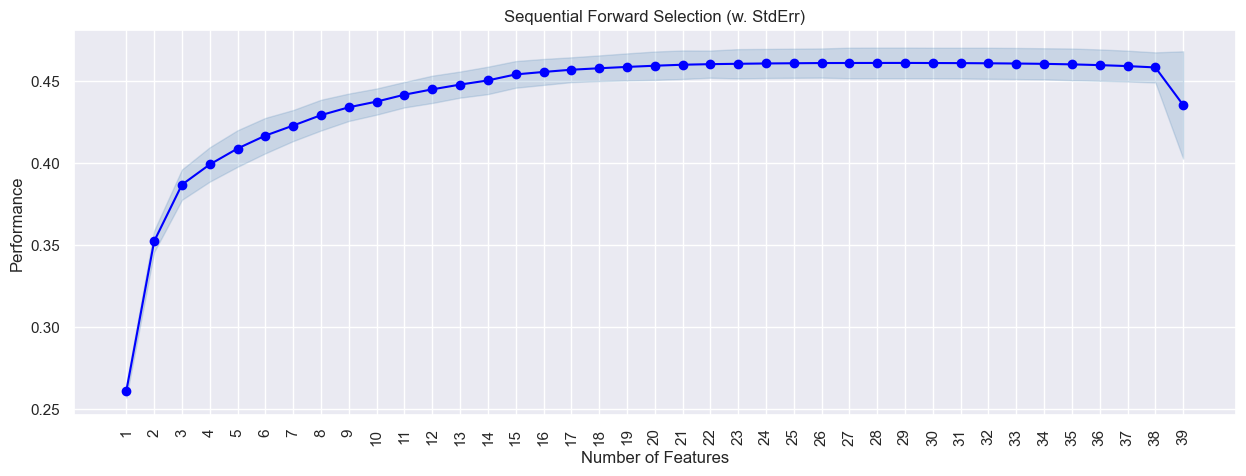

In [83]:
# to plot the performance with addition of each feature
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig1 = plot_sfs(sfs.get_metric_dict(), kind="std_err", figsize=(15, 5))
plt.title("Sequential Forward Selection (w. StdErr)")
plt.xticks(rotation=90)
plt.show()

### Describe the results

In [84]:
reg = LinearRegression()

# Build step forward feature selection
sfs = SFS(
    reg,
    k_features=30,
    forward=True,
    floating=False,
    scoring="r2",
    n_jobs=-1,
    verbose=2,
    cv=5,
)

# Perform SFFS
sfs = sfs.fit(x_train, y_train)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 out of  39 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  39 out of  39 | elapsed:    0.2s finished

[2024-04-04 12:40:14] Features: 1/30 -- score: 0.2610893595879031[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  35 out of  38 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  38 out of  38 | elapsed:    0.2s finished

[2024-04-04 12:40:14] Features: 2/30 -- score: 0.3522663085348248[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 out of  37 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  37 out of  37 | elapsed:    0.1s finished

[2024-04-04 12:40:15] Features: 3/30 -- score: 0.38675544868999195[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 out o

In [85]:
# let us select the features which are important
feat_cols = list(sfs.k_feature_idx_)
print(feat_cols)

[0, 2, 3, 4, 5, 6, 7, 9, 11, 12, 14, 15, 16, 17, 19, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 37]


In [86]:
# let us look at the names of the important features
x_train.columns[feat_cols]

Index(['mediaType', 'duration', 'ongoing', 'years_running', 'studios_colab',
       'contentWarn', 'watched', 'wantWatch', 'votes', 'tag_Based_on_a_Manga',
       'tag_Action', 'tag_Fantasy', 'tag_Sci_Fi', 'tag_Shounen',
       'tag_Non_Human_Protagonists', 'tag_Drama', 'tag_Family_Friendly',
       'tag_Short_Episodes', 'tag_School_Life', 'tag_Romance', 'tag_Shorts',
       'tag_Slice_of_Life', 'tag_Seinen', 'tag_Supernatural', 'tag_Magic',
       'tag_Animal_Protagonists', 'tag_Ecchi', 'tag_Mecha',
       'tag_Based_on_a_Light_Novel', 'tag_Others'],
      dtype='object')

**Now we will fit an sklearn model using these features only.**

In [87]:
x_train_final = x_train[x_train.columns[feat_cols]]

In [88]:
# Creating new x_test with the same 20 variables that we selected for x_train
x_test_final = x_test[x_train_final.columns]

In [89]:
# Fitting linear model
lin_reg_model2 = LinearRegression()
lin_reg_model2.fit(x_train_final, y_train)

# let us check the coefficients and intercept of the model

coef_df = pd.DataFrame(
    np.append(lin_reg_model2.coef_.flatten(), lin_reg_model2.intercept_),
    index=x_train_final.columns.tolist() + ["Intercept"],
    columns=["Coefficients"],
)
print(coef_df)

                            Coefficients
mediaType                      -0.007405
duration                        0.005392
ongoing                         0.540117
years_running                   0.025632
studios_colab                   0.134746
contentWarn                    -0.220472
watched                         0.000096
wantWatch                       0.000246
votes                          -0.000165
tag_Based_on_a_Manga            0.227119
tag_Action                      0.099601
tag_Fantasy                     0.181005
tag_Sci_Fi                      0.055429
tag_Shounen                     0.211562
tag_Non_Human_Protagonists      0.053905
tag_Drama                       0.276150
tag_Family_Friendly            -0.104630
tag_Short_Episodes             -0.236275
tag_School_Life                 0.088052
tag_Romance                     0.075460
tag_Shorts                     -0.279743
tag_Slice_of_Life               0.234756
tag_Seinen                      0.154170
tag_Supernatural

In [90]:
# model performance on train set
print("Training Performance\n")
lin_reg_model2_train_perf = model_performance_regression(
    lin_reg_model2, x_train_final, y_train
)
lin_reg_model2_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.608539,0.496479,0.468317,0.465246,20.867658,79.132342


In [91]:
# model performance on test set
print("Test Performance\n")
lin_reg_model2_test_perf = model_performance_regression(
    lin_reg_model2, x_test_final, y_test
)
lin_reg_model2_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.591817,0.485557,0.476285,0.469173,20.399924,79.600076


- There are no significant changes between this and the previous iteration

In [92]:
# training performance comparison

models_train_comp_df = pd.concat(
    [lin_reg_model_train_perf.T, lin_reg_model2_train_perf.T],
    axis=1,
)

models_train_comp_df.columns = [
    "Linear Regression sklearn",
    "Linear Regression sklearn (SFS features)",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Linear Regression sklearn,Linear Regression sklearn (SFS features)
RMSE,0.607325,0.608539
MAE,0.495215,0.496479
R-squared,0.470437,0.468317
Adj. R-squared,0.466454,0.465246
MAPE,20.825099,20.867658
Accuracy,79.174901,79.132342


In [93]:
# test performance comparison

models_test_comp_df = pd.concat(
    [lin_reg_model_test_perf.T, lin_reg_model2_test_perf.T],
    axis=1,
)

models_test_comp_df.columns = [
    "Linear Regression sklearn",
    "Linear Regression sklearn (SFS features)",
]

print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Linear Regression sklearn,Linear Regression sklearn (SFS features)
RMSE,0.589057,0.591817
MAE,0.483761,0.485557
R-squared,0.481157,0.476285
Adj. R-squared,0.471959,0.469173
MAPE,20.340527,20.399924
Accuracy,79.659473,79.600076


There aren't any significant differences between the two. In fact, it's almost impressive how similar the results are.

#### Linear Regression w/studio_primary column

In [94]:
# preparing alternative dataset to be used
data2.drop(['title', 'description', 'sznOfRelease'], axis=1, inplace=True)

In [95]:
data2.dropna(inplace=True)
data2.shape

(7465, 41)

In [96]:
data2['mediaType'] = label_encoder.fit_transform(data2['mediaType'])
data2['studio_primary'] = label_encoder.fit_transform(data2['studio_primary'])

In [97]:
X2 = data2.drop(["rating"], axis=1)
y2 = data2["rating"]

In [98]:
X2.shape

(7465, 40)

In [99]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=1)

In [100]:
lin_reg_model3 = LinearRegression()
lin_reg_model3.fit(x_train2, y_train2)

LinearRegression()

In [101]:
lin_reg_model3_train_perf = model_performance_regression(lin_reg_model3, x_train2, y_train2)
lin_reg_model3_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.602667,0.490627,0.478528,0.474504,20.609462,79.390538


In [102]:
lin_reg_model3_test_perf = model_performance_regression(lin_reg_model3, x_test2, y_test2)
lin_reg_model3_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.590365,0.483609,0.478851,0.469371,20.281111,79.718889


#### Forward Feature Selection w/studio_primary column

In [103]:
reg = LinearRegression()

# Build step forward feature selection
sfs = SFS(
    reg,
    k_features=30,
    forward=True,
    floating=False,
    scoring="r2",
    n_jobs=-1,
    verbose=2,
    cv=5,
)

# Perform SFFS
sfs = sfs.fit(x_train2, y_train2)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  38 out of  40 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:    0.2s finished

[2024-04-04 12:40:21] Features: 1/30 -- score: 0.2610893595879031[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 out of  39 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  39 out of  39 | elapsed:    0.2s finished

[2024-04-04 12:40:22] Features: 2/30 -- score: 0.3522663085348248[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  35 out of  38 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  38 out of  38 | elapsed:    0.2s finished

[2024-04-04 12:40:22] Features: 3/30 -- score: 0.38675544868999195[Parallel(n_jobs=-1)]: Using backend LokyBackend wit

In [104]:
feat_cols = list(sfs.k_feature_idx_)
print(feat_cols)

[0, 2, 3, 4, 5, 7, 8, 10, 12, 13, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


In [105]:
x_train2.columns[feat_cols]

Index(['mediaType', 'duration', 'ongoing', 'years_running', 'studio_primary',
       'contentWarn', 'watched', 'wantWatch', 'votes', 'tag_Based_on_a_Manga',
       'tag_Action', 'tag_Fantasy', 'tag_Sci_Fi', 'tag_Shounen',
       'tag_Original_Work', 'tag_Non_Human_Protagonists', 'tag_Drama',
       'tag_Family_Friendly', 'tag_Short_Episodes', 'tag_School_Life',
       'tag_Romance', 'tag_Shorts', 'tag_Slice_of_Life', 'tag_Seinen',
       'tag_Supernatural', 'tag_Magic', 'tag_Animal_Protagonists', 'tag_Ecchi',
       'tag_Mecha', 'tag_Based_on_a_Light_Novel'],
      dtype='object')

In [106]:
x_train2_final = x_train2[x_train2.columns[feat_cols]]

In [107]:
x_test2_final = x_test2[x_train2_final.columns]

In [108]:
lin_reg_model4 = LinearRegression()
lin_reg_model4.fit(x_train2_final, y_train2)

coef_df = pd.DataFrame(
    np.append(lin_reg_model4.coef_.flatten(), lin_reg_model4.intercept_),
    index=x_train2_final.columns.tolist() + ["Intercept"],
    columns=["Coefficients"]
)
print(coef_df)

                            Coefficients
mediaType                      -0.008305
duration                        0.005162
ongoing                         0.531384
years_running                   0.026266
studio_primary                 -0.014713
contentWarn                    -0.230216
watched                         0.000091
wantWatch                       0.000232
votes                          -0.000155
tag_Based_on_a_Manga            0.193138
tag_Action                      0.102544
tag_Fantasy                     0.162126
tag_Sci_Fi                      0.039855
tag_Shounen                     0.220259
tag_Original_Work              -0.049531
tag_Non_Human_Protagonists      0.048415
tag_Drama                       0.277209
tag_Family_Friendly            -0.100935
tag_Short_Episodes             -0.250451
tag_School_Life                 0.068101
tag_Romance                     0.070871
tag_Shorts                     -0.252598
tag_Slice_of_Life               0.223178
tag_Seinen      

In [109]:
print("Training Performance\n")
lin_reg_model4_train_perf = model_performance_regression(
    lin_reg_model4, x_train2_final, y_train2
)
lin_reg_model4_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.603947,0.491229,0.476312,0.473287,20.64162,79.35838


In [110]:
print("Test Performance\n")
lin_reg_model4_test_perf = model_performance_regression(
    lin_reg_model4, x_test2_final, y_test2
)
lin_reg_model4_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.593054,0.484965,0.474093,0.466951,20.341048,79.658952


In [111]:
models_test_comp_df = pd.concat(
    [lin_reg_model_test_perf.T, lin_reg_model2_test_perf.T, lin_reg_model3_test_perf.T, lin_reg_model4_test_perf.T],
    axis=1,
)

models_test_comp_df.columns = [
    "Linear Regression sklearn",
    "Linear Regression sklearn (SFS features)",
    "Lin. Reg. w/ studio_primary",
    "Lin. Reg. W/ studio_primary (SFS features)"
]

print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Linear Regression sklearn,Linear Regression sklearn (SFS features),Lin. Reg. w/ studio_primary,Lin. Reg. W/ studio_primary (SFS features)
RMSE,0.589057,0.591817,0.590365,0.593054
MAE,0.483761,0.485557,0.483609,0.484965
R-squared,0.481157,0.476285,0.478851,0.474093
Adj. R-squared,0.471959,0.469173,0.469371,0.466951
MAPE,20.340527,20.399924,20.281111,20.341048
Accuracy,79.659473,79.600076,79.718889,79.658952


<b>Conclusion:</b>
</br>
No significant difference

#### Linear Regression w/normalization

In [112]:
cols_to_std = ["eps", "duration", "watched", "watching", "wantWatch", "dropped", "votes"]

In [113]:
from sklearn.preprocessing import MinMaxScaler

In [114]:
scaler = MinMaxScaler()

for col in cols_to_std:
    data2[col] = scaler.fit_transform(data2[[col]])

In [115]:
X3 = data2.drop(["rating"], axis=1)
y3 = data2["rating"]

In [116]:
x_train3, x_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.3, random_state=1)

In [117]:
lin_reg_model5 = LinearRegression()
lin_reg_model5.fit(x_train3, y_train3)

LinearRegression()

In [118]:
lin_reg_model5_train_perf = model_performance_regression(lin_reg_model5, x_train3, y_train3)
lin_reg_model5_train_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.602667,0.490627,0.478528,0.474504,20.609462,79.390538


In [119]:
lin_reg_model5_test_perf = model_performance_regression(lin_reg_model5, x_test3, y_test3)
lin_reg_model5_test_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.590365,0.483609,0.478851,0.469371,20.281111,79.718889


### Random Forest

In [120]:
from sklearn.ensemble import RandomForestRegressor

In [121]:
rf = RandomForestRegressor(n_estimators=1000, random_state=35)
rf.fit(x_train2, y_train2)

RandomForestRegressor(n_estimators=1000, random_state=35)

In [122]:
print("Training Performance\n")
rf_model_train_perf = model_performance_regression(rf, x_train2, y_train2)
rf_model_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.175251,0.137144,0.955904,0.955564,5.782566,94.217434


In [123]:
print("Test Performance\n")
rf_model_test_perf = model_performance_regression(rf, x_test2, y_test2)
rf_model_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Accuracy
0,0.45375,0.357343,0.69214,0.68654,15.029018,84.970982


<b>Observations:</b>
<ul>
    <li>Clear signs of overfit</li>
</ul>

#### Random Forest w/normalization

In [124]:
reg = RandomForestRegressor()

# Build step forward feature selection
sfs = SFS(
    reg,
    k_features=30,
    forward=True,
    floating=False,
    scoring="r2",
    n_jobs=-1,
    verbose=2,
    cv=5,
)

# Perform SFFS
sfs = sfs.fit(x_train2, y_train2)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  38 out of  40 | elapsed:    3.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  40 out of  40 | elapsed:    3.1s finished

[2024-04-04 12:41:00] Features: 1/30 -- score: 0.3634756123197335[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  36 out of  39 | elapsed:    9.2s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done  39 out of  39 | elapsed:    9.4s finished

[2024-04-04 12:41:09] Features: 2/30 -- score: 0.4310464840015311[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  35 out of  38 | elapsed:   12.0s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done  38 out of  38 | elapsed:   13.1s finished

[2024-04-04 12:41:22] Features: 3/30 -- score: 0.4970221031833004[Parallel(n_jobs=-1)]: Using backend LokyBackend with

In [125]:
feat_cols = list(sfs.k_feature_idx_)
print(feat_cols)

TypeError: 'NoneType' object is not iterable

In [ ]:
x_train2.columns[feat_cols]

In [ ]:
x_train2_final2 = x_train2[x_train2.columns[feat_cols]]

In [ ]:
x_test2_final2 = x_test2[x_train2_final2.columns]

In [ ]:
rf2 = RandomForestRegressor()
rf2.fit(x_train2_final2, y_train2)

In [ ]:
rf2_model_train_perf = model_performance_regression(rf2, x_train2_final2, y_train2)
rf2_model_train_perf

In [ ]:
rf2_model_test_perf = model_performance_regression(rf2, x_test2_final2, y_test2)
rf2_model_test_perf

In [ ]:
models_test_comp_df = pd.concat(
    [rf_model_test_perf.T, rf2_model_test_perf.T], 
    axis=1
)

models_test_comp_df.columns = [
    "Random Forest",
    "Random Forest (SFS features)"
]
print("Test performance comparison:")
models_test_comp_df

## Conclusions

In [ ]:
models_test_comp_df = pd.concat(
    [rf_model_test_perf.T, rf2_model_test_perf.T,
    lin_reg_model5_test_perf], axis=1
)

models_test_comp_df.columns = [
    "Random Forest",
    "Random Forest (SFS features)",
    "Linear Regression (Norm)"
]

Ultimately, the changes that were made to the two models (Linear Regression, and Random Forest) didn't net any significant changes. There were marginal increases in accuracy with changes to LR, but RF is too prone to overfit for there to be any considerable difference in the results, it seems.

Because of this, the LR model is likely superior for this dataset. In the future, when running into overfit issues, SVM is likely the best model to try. 